In [1]:
import ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
autistic_spectrum_disorder_screening_data_for_children = fetch_ucirepo(id=419) 
  
# data (as pandas dataframes) 
X = autistic_spectrum_disorder_screening_data_for_children.data.features 
y = autistic_spectrum_disorder_screening_data_for_children.data.targets 
  
# metadata 
print(autistic_spectrum_disorder_screening_data_for_children.metadata) 
  
# variable information 
print(autistic_spectrum_disorder_screening_data_for_children.variables) 

{'uci_id': 419, 'name': 'Autistic Spectrum Disorder Screening Data for Children  ', 'repository_url': 'https://archive.ics.uci.edu/dataset/419/autistic+spectrum+disorder+screening+data+for+children', 'data_url': 'https://archive.ics.uci.edu/static/public/419/data.csv', 'abstract': 'Children screening data for autism suitable for classification and predictive tasks ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 292, 'num_features': 20, 'feature_types': ['Integer'], 'demographics': ['\x00', 'Age', 'Gender', 'Ethnicity', 'Nationality'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2017, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5659W', 'creators': ['Fadi Thabtah'], 'intro_paper': None, 'additional_info': {'summary': "see attached file for variables' description ", 'purpose': None, 'funded_by': None, 'instances_repr

## Basic EDA

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.concat([X, y], axis=1)
df.shape

(292, 21)

In [ ]:
from pathlib import Path

output_dir = Path("../../data/questionnaire")
output_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(output_dir / "asd_screening_children.csv", index=False)

In [4]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,0,0,1,1,0,1,0,0,6.0,m,Others,no,no,Jordan,no,5,'4-11 years',Parent,NO
1,1,1,0,0,1,1,0,1,0,0,6.0,m,'Middle Eastern ',no,no,Jordan,no,5,'4-11 years',Parent,NO
2,1,1,0,0,0,1,1,1,0,0,6.0,m,NaN,no,no,Jordan,yes,5,'4-11 years',NaN,NO
3,0,1,0,0,1,1,0,0,0,1,5.0,f,NaN,yes,no,Jordan,no,4,'4-11 years',NaN,NO
4,1,1,1,1,1,1,1,1,1,1,5.0,m,Others,yes,no,'United States',no,10,'4-11 years',Parent,YES


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         292 non-null    int64  
 1   A2_Score         292 non-null    int64  
 2   A3_Score         292 non-null    int64  
 3   A4_Score         292 non-null    int64  
 4   A5_Score         292 non-null    int64  
 5   A6_Score         292 non-null    int64  
 6   A7_Score         292 non-null    int64  
 7   A8_Score         292 non-null    int64  
 8   A9_Score         292 non-null    int64  
 9   A10_Score        292 non-null    int64  
 10  age              288 non-null    float64
 11  gender           292 non-null    object 
 12  ethnicity        249 non-null    object 
 13  jaundice         292 non-null    object 
 14  autism           292 non-null    object 
 15  country_of_res   292 non-null    object 
 16  used_app_before  292 non-null    object 
 17  result          

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1_Score,292.0,NaN,NaN,NaN,0.633562,0.482658,0.0,0.0,1.0,1.0,1.0
A2_Score,292.0,NaN,NaN,NaN,0.534247,0.499682,0.0,0.0,1.0,1.0,1.0
A3_Score,292.0,NaN,NaN,NaN,0.743151,0.437646,0.0,0.0,1.0,1.0,1.0
A4_Score,292.0,NaN,NaN,NaN,0.55137,0.498208,0.0,0.0,1.0,1.0,1.0
A5_Score,292.0,NaN,NaN,NaN,0.743151,0.437646,0.0,0.0,1.0,1.0,1.0
A6_Score,292.0,NaN,NaN,NaN,0.712329,0.453454,0.0,0.0,1.0,1.0,1.0
A7_Score,292.0,NaN,NaN,NaN,0.606164,0.489438,0.0,0.0,1.0,1.0,1.0
A8_Score,292.0,NaN,NaN,NaN,0.496575,0.500847,0.0,0.0,0.0,1.0,1.0
A9_Score,292.0,NaN,NaN,NaN,0.493151,0.500811,0.0,0.0,0.0,1.0,1.0
A10_Score,292.0,NaN,NaN,NaN,0.726027,0.446761,0.0,0.0,1.0,1.0,1.0


### Missing values

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct}).query("n_missing > 0")

,n_missing,pct_missing
age,4,1.37
ethnicity,43,14.73
relation,43,14.73


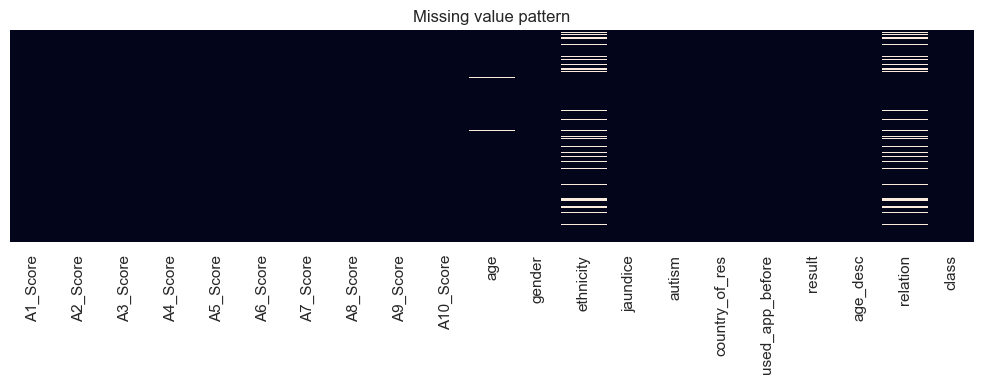

In [8]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missing value pattern")
plt.tight_layout()
plt.show()

### Target distribution (`class`)

class
NO     151
YES    141
Name: count, dtype: int64
class
NO     51.71
YES    48.29
Name: count, dtype: float64


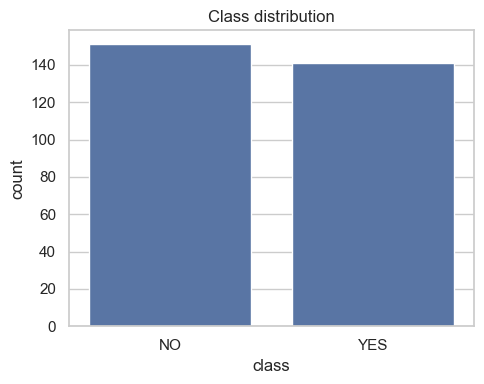

In [9]:
target_col = "class"
counts = df[target_col].value_counts()
print(counts)
print((counts / len(df) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=df, order=counts.index)
plt.title("Class distribution")
plt.tight_layout()
plt.show()

### Numeric feature distributions (`age`, `result`)

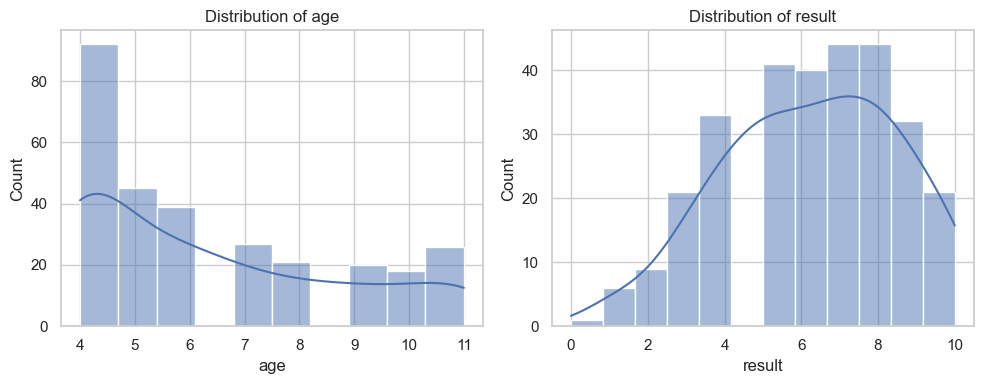

In [10]:
numeric_cols = ["age", "result"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

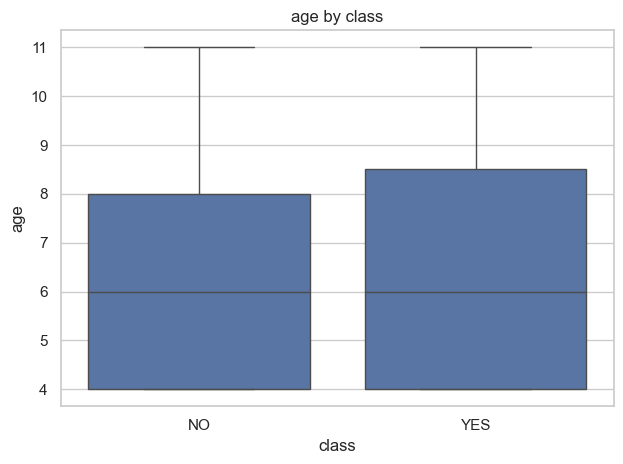

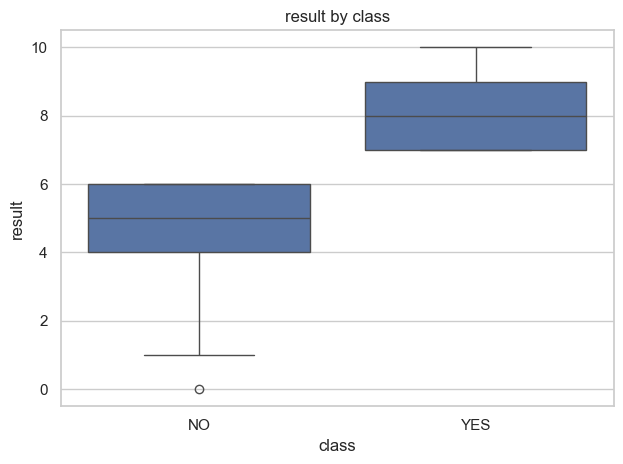

In [11]:
for col in numeric_cols:
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by {target_col}")
    plt.tight_layout()
    plt.show()

### Categorical feature distributions

In [12]:
categorical_cols = [
    "gender", "ethnicity", "jaundice", "autism",
    "country_of_res", "used_app_before", "age_desc", "relation",
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- gender ---
gender
m    208
f     84
Name: count, dtype: int64

--- ethnicity ---
ethnicity
White-European       108
Asian                 46
NaN                   43
'Middle Eastern '     27
'South Asian'         21
Others                14
Black                 14
Latino                 8
Hispanic               7
Pasifika               2
Turkish                2
Name: count, dtype: int64

--- jaundice ---
jaundice
no     212
yes     80
Name: count, dtype: int64

--- autism ---
autism
no     243
yes     49
Name: count, dtype: int64

--- country_of_res ---
country_of_res
'United Kingdom'           49
'United States'            42
India                      42
Australia                  23
Jordan                     20
'New Zealand'              13
Egypt                       9
'United Arab Emirates'      7
Canada                      7
Bangladesh                  6
'Saudi Arabia'              4
Philippines                 4
Pakistan                    4
Libya                       3

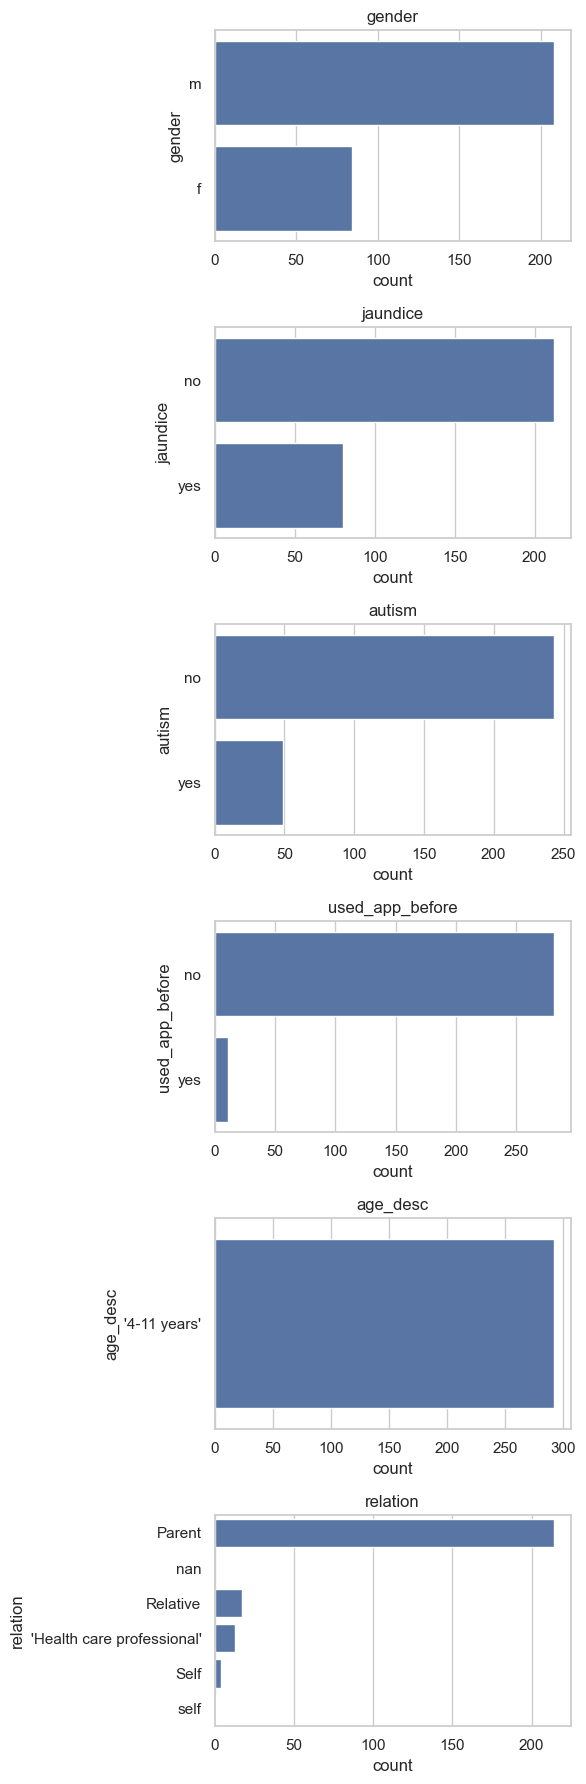

In [13]:
low_cardinality_cols = [c for c in categorical_cols if df[c].nunique(dropna=False) <= 10]

fig, axes = plt.subplots(len(low_cardinality_cols), 1, figsize=(6, 3 * len(low_cardinality_cols)))
for ax, col in zip(axes, low_cardinality_cols):
    sns.countplot(y=col, data=df, order=df[col].value_counts(dropna=False).index, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Screening item scores (`A1_Score`–`A10_Score`)

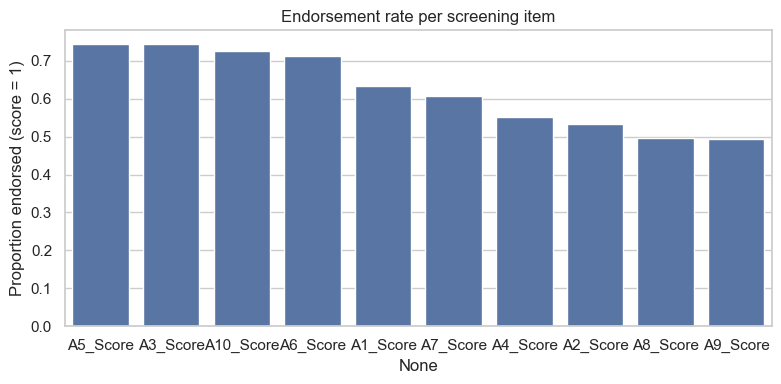

In [14]:
score_cols = [f"A{i}_Score" for i in range(1, 11)]

score_endorsement = df[score_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=score_endorsement.index, y=score_endorsement.values)
plt.ylabel("Proportion endorsed (score = 1)")
plt.title("Endorsement rate per screening item")
plt.tight_layout()
plt.show()

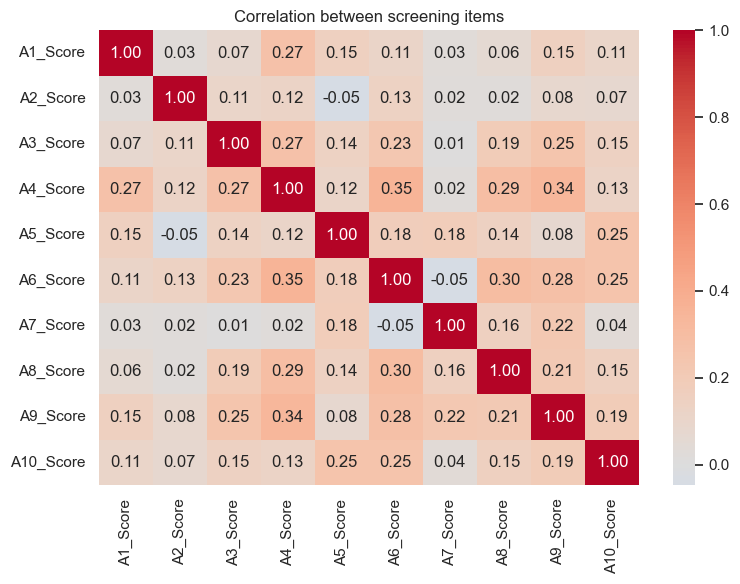

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[score_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between screening items")
plt.tight_layout()
plt.show()